# Mass Composition Analysis and Sensitivity tests

This script processes snowpack profile data from multiple buoys and visualizes the seasonal snow composition as a grid of pie charts. Each pie chart represents the relative mass fractions of snow/ice categories for a given buoy under a baseline scenario and multiple climate scenarios.

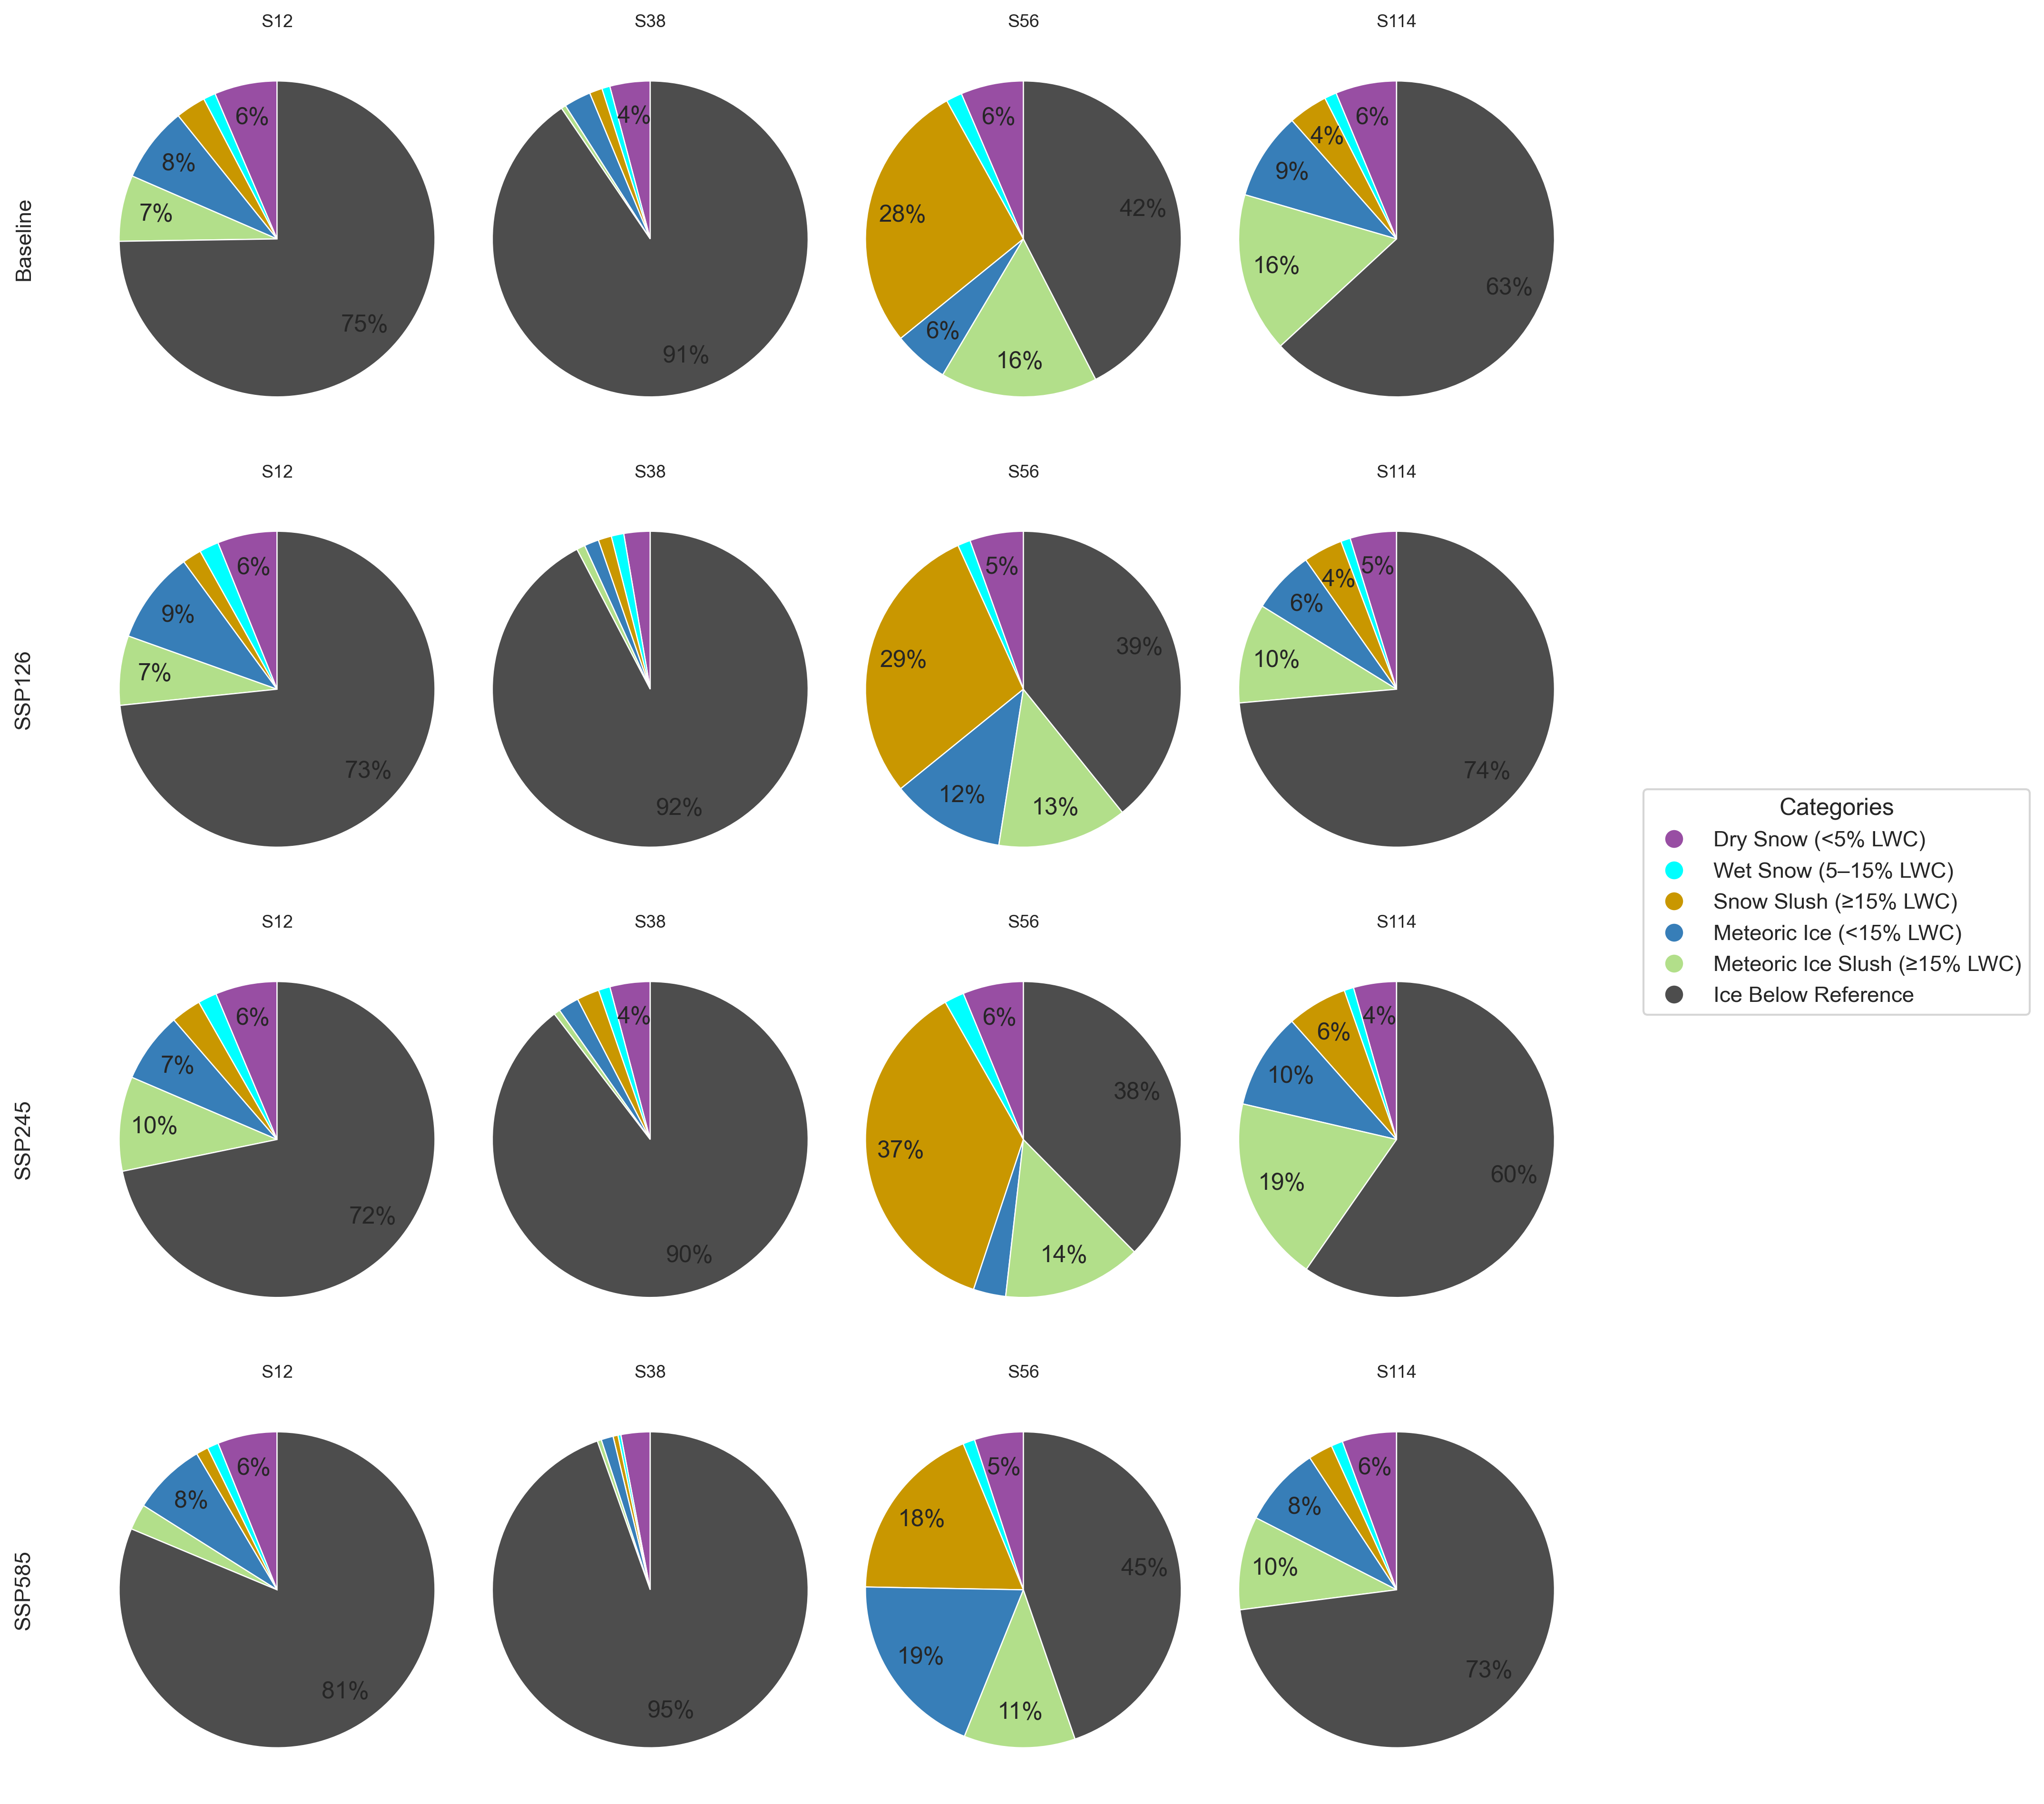

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- Config ---
THICK_TO_M = 0.01  # 0.01 if "layer thickness" is in cm; set to 1.0 if already meters
BUOYS      = ["S12", "S38", "S56", "S114"]
SCENARIOS  = ["SSP126", "SSP245", "SSP585"]  # columns after Baseline

# File paths (as you defined earlier)
STATION_FILES = {
    "S114_Baseline": "S114_S114_OHF_5_2cm_dyn_sal_1h_TAera5_NO_Baseline.pro",
    "S12_Baseline":  "S12_S12_OHF_5_2cm_dyn_sal_1h_TAera5_NO_Baseline.pro",
    "S38_Baseline":  "S38_S38_OHF_5_2cm_dyn_sal_1h_TAera5_NO_Baseline.pro",
    "S56_Baseline":  "S56_S56_OHF_5_2cm_dyn_sal_1h_TAera5_NO_Baseline.pro",

    "S114_SSP126":   "S114_S114_OHF_5_2cm_dyn_sal_1h_TAera5_NO_SSP126.pro",
    "S12_SSP126":    "S12_S12_OHF_5_2cm_dyn_sal_1h_TAera5_NO_SSP126.pro",
    "S38_SSP126":    "S38_S38_OHF_5_2cm_dyn_sal_1h_TAera5_NO_SSP126.pro",
    "S56_SSP126":    "S56_S56_OHF_5_2cm_dyn_sal_1h_TAera5_NO_SSP126.pro",

    "S114_SSP245":   "S114_S114_OHF_5_2cm_dyn_sal_1h_TAera5_NO_SSP245.pro",
    "S12_SSP245":    "S12_S12_OHF_5_2cm_dyn_sal_1h_TAera5_NO_SSP245.pro",
    "S38_SSP245":    "S38_S38_OHF_5_2cm_dyn_sal_1h_TAera5_NO_SSP245.pro",
    "S56_SSP245":    "S56_S56_OHF_5_2cm_dyn_sal_1h_TAera5_NO_SSP245.pro",

    "S114_SSP585":   "S114_S114_OHF_5_2cm_dyn_sal_1h_TAera5_NO_SSP585.pro",
    "S12_SSP585":    "S12_S12_OHF_5_2cm_dyn_sal_1h_TAera5_NO_SSP585.pro",
    "S38_SSP585":    "S38_S38_OHF_5_2cm_dyn_sal_1h_TAera5_NO_SSP585.pro",
    "S56_SSP585":    "S56_S56_OHF_5_2cm_dyn_sal_1h_TAera5_NO_SSP585.pro",
}

# --- Categories (order and colors) ---
cat_ids = [1, 2, 3, 4, 5, 7]

group_labels = {
    1: "Dry Snow (<5% LWC)",
    2: "Wet Snow (5–15% LWC)",
    3: "Snow Slush (≥15% LWC)",
    4: "Meteoric Ice (<15% LWC)",
    5: "Meteoric Ice Slush (≥15% LWC)",
    7: "Ice Below Reference",
}

group_colors = {
    1: "#984ea3",
    2: "#00ffff",
    3: "#c99700",
    4: "#377eb8",
    5: "#b2df8a",
    7: "#4d4d4d",
}

# --- Helpers: read & compute mass by category ---
from snowpat import snowpackreader as spr

def group_mk(mk, lwc, above_ref=True):
    if mk in {0,1,2}:
        return 1 if lwc < 5 else 2 if lwc < 15 else 3
    if mk in {11,12,21,22}:
        return 2 if lwc < 15 else 3
    if mk in {7,8,17,18,27,28}:
        if above_ref:
            return 4 if lwc < 15 else 5
        else:
            return 7  # Ice below reference
    if mk in {9007,9017,9027}:
        return 6
    return 0

def read_pro(path):
    pro = spr.readPRO(path)
    pro.discard_below_ground(discard=False)
    return pro

def mass_means_by_category(pro_obj):
    """Return period-mean mass per unit area for C1..C5 (kg m^-2) as a dict {cid: mean}."""
    dates    = pro_obj.get_all_dates()
    profiles = pro_obj.get_all_profiles()
    series = {cid: [] for cid in cat_ids}

    for prof in profiles:
        dfp = prof.toDf(CodesToName=pro_obj.DataCodes)
        mk    = dfp["element mk"].values
        lwc   = dfp["liquid water content by volume"].values
        thick = dfp["layer thickness"].values      # usually cm
        rho   = dfp["element density"].values      # kg m^-3

        # find reference (first marker)
        idx_ref = np.where(np.isin(mk, [9007,9017,9027]))[0]
        i0      = idx_ref[0] if idx_ref.size else -1

        mk_above    = mk[i0+1:]
        lwc_above   = lwc[i0+1:]
        thick_above = thick[i0+1:]
        rho_above   = rho[i0+1:]

        mk_below    = mk[:i0+1]
        lwc_below   = lwc[:i0+1]
        thick_below = thick[:i0+1]
        rho_below   = rho[:i0+1]

        grp_above = np.array([group_mk(m, l, above_ref=True)  for m, l in zip(mk_above, lwc_above)])
        grp_below = np.array([group_mk(m, l, above_ref=False) for m, l in zip(mk_below, lwc_below)])

        h_m_above = thick_above * THICK_TO_M  # m
        h_m_below = thick_below * THICK_TO_M  # m

        for cid in cat_ids:
            if cid == 7:
                mask = (grp_below == cid)
                series[cid].append(np.nansum(rho_below[mask] * h_m_below[mask]))  # kg m^-2
            else:
                mask = (grp_above == cid)
                series[cid].append(np.nansum(rho_above[mask] * h_m_above[mask]))  # kg m^-2

    # period means (simple mean over timestamps)
    means = {cid: float(np.nanmean(series[cid])) if len(series[cid]) else 0.0
             for cid in cat_ids}
    return means

# --- Prepare composition data: percent per category for each Buoy × (Baseline+Scenarios) ---
columns = ["Baseline"] + SCENARIOS
# nested dict: comp[buoy][col] = list of percentages in category order
comp = {b: {c: [0]*len(cat_ids) for c in columns} for b in BUOYS}

for buoy in BUOYS:
    # Baseline
    base_key = f"{buoy}_Baseline"
    base_means = mass_means_by_category(read_pro(STATION_FILES[base_key]))
    base_vals = [base_means[cid] for cid in cat_ids]
    base_total = sum(base_vals)
    comp[buoy]["Baseline"] = [ (v/base_total*100 if base_total>0 else 0.0) for v in base_vals ]

    # Scenarios
    for scen in SCENARIOS:
        scen_key = f"{buoy}_{scen}"
        scen_means = mass_means_by_category(read_pro(STATION_FILES[scen_key]))
        scen_vals = [scen_means[cid] for cid in cat_ids]
        scen_total = sum(scen_vals)
        comp[buoy][scen] = [ (v/scen_total*100 if scen_total>0 else 0.0) for v in scen_vals ]

# --- Plot grid of pies: rows = scenarios, cols = buoys ---
scenarios_all = ["Baseline"] + SCENARIOS
nrows = len(scenarios_all)
ncols = len(BUOYS)
fig, axes = plt.subplots(nrows, ncols, figsize=(3.2*ncols, 3.2*nrows), dpi=300, squeeze=False)

labels = [group_labels[cid] for cid in cat_ids]
colors = [group_colors[cid] for cid in cat_ids]

def autopct_pct(threshold=3.0):
    def _fmt(pct):
        return f"{pct:.0f}%" if pct >= threshold else ""
    return _fmt

for i, scen in enumerate(scenarios_all):
    for j, buoy in enumerate(BUOYS):
        ax = axes[i, j]
        sizes = comp[buoy][scen]
        total_pct = sum(sizes)
        if total_pct <= 0:
            ax.text(0.5, 0.5, "No data", ha="center", va="center")
            ax.axis("off")
            continue

        wedges, _texts, autotexts = ax.pie(
            sizes,
            labels=None,
            colors=colors,
            startangle=90,
            autopct=autopct_pct(4.0),
            pctdistance=0.78,
            wedgeprops=dict(linewidth=0.6, edgecolor="white")
        )
        ax.set_title(f"{buoy}", fontsize=9)
        ax.axis("equal")

    # Add row label (scenario) on left side
    axes[i,0].set_ylabel(scen, fontsize=11, rotation=90, labelpad=40, va="center")

# Shared legend on the right
fig.legend(
    handles=[plt.Line2D([0],[0], marker='o', lw=0, markersize=10, markerfacecolor=c, markeredgecolor="white")
             for c in colors],
    labels=labels,
    loc="center left",
    bbox_to_anchor=(0.9, 0.5),
    title="Categories"
)

plt.tight_layout(rect=(0,0,0.88,1))  # leave room for legend
plt.show()

## Sensitivity tests

This script performs a sensitivity analysis of snowpack mass distribution under climate perturbations for multiple buoys and visualizes the results. It reads snow profile data for a baseline and four perturbation scenarios (±1 °C phase change and ±10 % precipitation change) using the snowpat library. Snow and ice layers are classified into physical categories based on markers and liquid water content, and the mass per category (kg m⁻²) is computed over time.

For each buoy, the script calculates the change in total and category-specific mass between each perturbation and the baseline, producing a structured sensitivity table. The differences are then visualized as errorbar plots, where each subplot corresponds to a buoy and each point represents the mass response of a snow/ice category to a given perturbation. The error bars represent variability between paired perturbations (positive vs. negative).


=== Sensitivity table (Δ = variant – baseline), SSP245 ===
Buoy    Variant     Type Setting      ΔC1      ΔC2      ΔC3      ΔC4      ΔC5      ΔC7    ΔCtot
S114   baseline baseline       0    0.000    0.000    0.000    0.000    0.000    0.000    0.000
S114   phase:+1    phase      +1    0.000    0.000   14.776    1.162    0.881    2.198   16.819
S114   phase:-1    phase      -1   -5.797    3.566   -8.221   16.085  -10.609   11.051   -4.975
S114 precip:+10   precip     +10    2.497   -1.991    0.035   -0.257   39.452  -16.408   39.736
S114 precip:-10   precip     -10   -4.045   -2.055   -8.221   15.322  -29.762   30.522  -28.761
 S12   baseline baseline       0    0.000    0.000    0.000    0.000    0.000    0.000    0.000
 S12   phase:+1    phase      +1    0.000    0.000    0.000   56.926  -67.412  -17.846  -10.486
 S12   phase:-1    phase      -1    0.000    0.000    0.000  -40.651   24.668    3.932  -15.983
 S12 precip:+10   precip     +10    0.000    0.000    0.000  132.046 -120.64

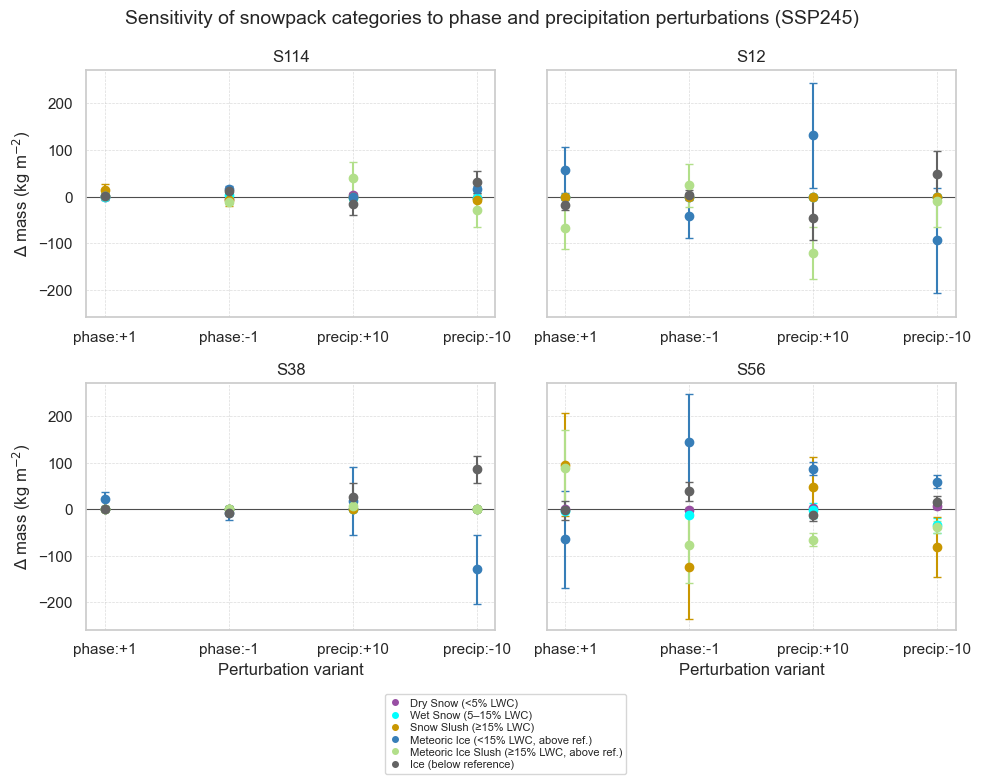

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import seaborn as sns
from pathlib import Path

from snowpat import snowpackreader as spr

sns.set_theme(style="whitegrid")

# ============================= USER CONFIG =============================
SCENARIO = "SSP245"
BUOYS = ["S12", "S38", "S56", "S114"]  # computation order
THICK_TO_M = 0.01
DROP_BELOW_GROUND = False

# For every buoy, expect these 5 files:
#   {B}_{B}_..._{SCENARIO}.pro          -> baseline (phase 0, precip 0)
#   {B}_{B}_..._{SCENARIO}_+1.pro       -> phase +1 °C
#   {B}_{B}_..._{SCENARIO}_-1.pro       -> phase -1 °C
#   {B}_{B}_..._{SCENARIO}_+10.pro      -> precip +10 %
#   {B}_{B}_..._{SCENARIO}_-10.pro      -> precip -10 %
def pro_name(station, suffix=""):
    base = f"{station}_{station}_OHF_5_2cm_dyn_sal_1h_TAera5_NO_{SCENARIO}"
    return base + (suffix if suffix == "" else f"{suffix}") + ".pro"

SENS_VARIANTS = {
    "phase:+1": "_+1",
    "phase:-1": "_-1",
    "precip:+10": "_+10",
    "precip:-10": "_-10",
}

# ======================== GROUPING / UTILITIES ==========================
def group_mk(mk, lwc, above_ref=True):
    """
    above_ref = True  -> meteoric ice categories (4/5)
    above_ref = False -> plain ice category (7)
    """
    # Snow types
    if mk in {0, 1, 2}:
        return 1 if lwc < 5 else 2 if lwc < 15 else 3
    if mk in {11, 12, 21, 22}:
        return 2 if lwc < 15 else 3

    # Ice / meteoric ice
    if mk in {7, 8, 17, 18, 27, 28}:
        if above_ref:
            # Meteoric ice as before
            return 4 if lwc < 15 else 5
        else:
            # New category: "just ice" below reference
            return 7

    # Reference
    if mk in {9007, 9017, 9027}:
        return 6

    # Other
    return 0

group_labels = {
    1: "Dry Snow (<5% LWC)",
    2: "Wet Snow (5–15% LWC)",
    3: "Snow Slush (≥15% LWC)",
    4: "Meteoric Ice (<15% LWC, above ref.)",
    5: "Meteoric Ice Slush (≥15% LWC, above ref.)",
    6: "Reference",
    7: "Ice (below reference)",
    0: "Other"
}

group_colors = {
    1: "#984ea3",
    2: "#00ffff",
    3: "#c99700",
    4: "#377eb8",
    5: "#b2df8a",
    6: "#000000",
    7: "#636363",  # Ice (below reference)
    0: "#999999"
}

# categories for which we want ΔC values
cat_ids = [1, 2, 3, 4, 5, 7]


def build_mass_series_from_pro(pro_obj):
    dates = pro_obj.get_all_dates()
    profiles = pro_obj.get_all_profiles()
    mass_series = {cid: [] for cid in cat_ids}

    for prof in profiles:
        dfp = prof.toDf(CodesToName=pro_obj.DataCodes)
        mk   = dfp["element mk"].values
        lwc  = dfp["liquid water content by volume"].values
        thick= dfp["layer thickness"].values
        rho  = dfp["element density"].values

        # find reference layer
        idx_ref = np.where(np.isin(mk, [9007, 9017, 9027]))[0]
        if idx_ref.size:
            i_ref = idx_ref[0]
        else:
            # if no reference, treat everything as "above"
            i_ref = -1

        h_m = thick * THICK_TO_M  # m

        # classify each layer with above/below reference info
        grp = []
        for k, (m, l) in enumerate(zip(mk, lwc)):
            above_ref = (k > i_ref)
            grp.append(group_mk(m, l, above_ref=above_ref))
        grp = np.array(grp)

        for cid in cat_ids:
            mask = (grp == cid)
            mass_series[cid].append(np.nansum(rho[mask] * h_m[mask]))

    df_mass = pd.DataFrame(
        {f"C{cid}": np.asarray(mass_series[cid], dtype=float) for cid in cat_ids},
        index=pd.to_datetime(dates)
    ).sort_index()

    # total: only snow + meteoric ice above ref (1–5)
    df_mass["Ctot"] = df_mass[[f"C{cid}" for cid in [1, 2, 3, 4, 5]]].sum(axis=1)
    return df_mass


def period_change(series: pd.Series) -> float:
    return float(series.iloc[-1] - series.iloc[0])


# ===================== BUILD SENSITIVITY TABLE =========================
all_rows = []

for buoy in BUOYS:
    # baseline
    base_path = Path(pro_name(buoy, ""))
    if not base_path.exists():
        print(f"[WARN] Baseline file missing for {buoy}: {base_path}")
        continue

    pro_base = spr.readPRO(str(base_path))
    pro_base.discard_below_ground(discard=DROP_BELOW_GROUND)
    df_base = build_mass_series_from_pro(pro_base)

    base_changes = {f"ΔC{cid}": 0.0 for cid in cat_ids}
    base_changes["ΔCtot"] = 0.0

    all_rows.append({
        "Buoy": buoy,
        "Variant": "baseline",
        "Type": "baseline",
        "Setting": "0",
        **base_changes
    })

    # sensitivities
    for key, suff in SENS_VARIANTS.items():
        var_path = Path(pro_name(buoy, suff))
        if not var_path.exists():
            print(f"[WARN] Variant missing for {buoy} ({key}): {var_path}")
            continue

        pro_var = spr.readPRO(str(var_path))
        pro_var.discard_below_ground(discard=DROP_BELOW_GROUND)
        df_var = build_mass_series_from_pro(pro_var)

        common_idx = df_base.index.intersection(df_var.index)
        dfb = df_base.loc[common_idx]
        dfv = df_var.loc[common_idx]

        row = {
            "Buoy": buoy,
            "Variant": key,
            "Type": key.split(":")[0],
            "Setting": key.split(":")[1],
        }
        for cid in cat_ids:
            d_base = period_change(dfb[f"C{cid}"])
            d_var  = period_change(dfv[f"C{cid}"])
            row[f"ΔC{cid}"] = d_var - d_base

        d_base_tot = period_change(dfb["Ctot"])
        d_var_tot  = period_change(dfv["Ctot"])
        row["ΔCtot"] = d_var_tot - d_base_tot

        all_rows.append(row)

sens_table = pd.DataFrame(all_rows)
col_order = ["Buoy", "Variant", "Type", "Setting",
             "ΔC1", "ΔC2", "ΔC3", "ΔC4", "ΔC5", "ΔC7", "ΔCtot"]
sens_table = sens_table[col_order].sort_values(["Buoy", "Type", "Setting"])

print(f"\n=== Sensitivity table (Δ = variant – baseline), {SCENARIO} ===")
print(sens_table.to_string(index=False, float_format=lambda x: f"{x:8.3f}"))

# ======================= BUILD DF FOR PLOTTING =========================
plot_table = sens_table[sens_table["Variant"] != "baseline"].copy()

df = pd.DataFrame({
    "Buoy":          plot_table["Buoy"],
    "Variant":       plot_table["Variant"],
    "Dry snow":      plot_table["ΔC1"],
    "Wet snow":      plot_table["ΔC2"],
    "Snow slush":    plot_table["ΔC3"],
    "Meteoric ice":  plot_table["ΔC4"],
    "Ice slush":     plot_table["ΔC5"],
    "Ice below ref": plot_table["ΔC7"],
    "Delta_C_tot":   plot_table["ΔCtot"],  # not plotted, but kept if needed
})


# ======================= ERRORBAR PLOT (COMBINED) ======================
def make_sensitivity_plot(df):
    # ---- Category -> pretty label and color ----
    label_map = {
        "Dry snow":      "Dry Snow (<5% LWC)",
        "Wet snow":      "Wet Snow (5–15% LWC)",
        "Snow slush":    "Snow Slush (≥15% LWC)",
        "Meteoric ice":  "Meteoric Ice (<15% LWC, above ref.)",
        "Ice slush":     "Meteoric Ice Slush (≥15% LWC, above ref.)",
        "Ice below ref": "Ice (below reference)",
    }

    color_map = {
        "Dry snow":      "#984ea3",
        "Wet snow":      "#00ffff",
        "Snow slush":    "#c99700",
        "Meteoric ice":  "#377eb8",
        "Ice slush":     "#b2df8a",
        "Ice below ref": "#636363",
    }

    categories = list(label_map.keys())

    variant_order = ["phase:+1", "phase:-1", "precip:+10", "precip:-10"]
    buoy_order = ["S114", "S12", "S38", "S56"]

    # ---- Compute error bars as standard deviations for ± pairs ----
    df_err = df.copy()
    for col in categories:
        df_err[col] = 0.0

    pairs = [("phase:+1", "phase:-1"), ("precip:+10", "precip:-10")]

    for buoy in df["Buoy"].unique():
        mask_b = df["Buoy"] == buoy
        for vplus, vminus in pairs:
            idx_plus_list  = df.index[mask_b & (df["Variant"] == vplus)]
            idx_minus_list = df.index[mask_b & (df["Variant"] == vminus)]
            if len(idx_plus_list) == 0 or len(idx_minus_list) == 0:
                continue  # skip if one of the pair is missing
            idx_plus  = idx_plus_list[0]
            idx_minus = idx_minus_list[0]
            for col in categories:
                vals = np.array([df.loc[idx_plus, col], df.loc[idx_minus, col]])
                err = np.std(vals, ddof=0)  # population std
                df_err.loc[idx_plus, col]  = err
                df_err.loc[idx_minus, col] = err

    # ---- Plotting ----
    fig, axes = plt.subplots(2, 2, figsize=(10, 7), sharey=True)
    axes = axes.flatten()

    for ax, buoy in zip(axes, buoy_order):
        g = (
            df[(df["Buoy"] == buoy) & (df["Variant"].isin(variant_order))]
            .set_index("Variant")
            .loc[variant_order]
            .reset_index()
        )
        g_err = (
            df_err[(df_err["Buoy"] == buoy) & (df_err["Variant"].isin(variant_order))]
            .set_index("Variant")
            .loc[variant_order]
            .reset_index()
        )

        x = np.arange(len(g))

        ax.grid(True, linestyle="--", linewidth=0.5, alpha=0.7)
        ax.axhline(0.0, color="0.3", linewidth=0.8, linestyle="-")

        for cat in categories:
            y    = g[cat].values
            yerr = g_err[cat].values

            ax.errorbar(
                x,
                y,
                yerr=yerr,
                fmt="o",
                capsize=3,
                label=label_map[cat],
                color=color_map[cat],
            )

        ax.set_xticks(list(x))
        ax.set_xticklabels(g["Variant"], rotation=0)
        ax.set_title(f"{buoy}")

        if ax in (axes[0], axes[2]):
            ax.set_ylabel("Δ mass (kg m$^{-2}$)")
        if ax in (axes[2], axes[3]):
            ax.set_xlabel("Perturbation variant")

    # --- Custom legend handles (proxies) ---
    legend_categories = categories
    legend_handles = [
        Line2D(
            [0], [0],
            marker="o",
            linestyle="none",
            markersize=4,
            color=color_map[cat],
        )
        for cat in legend_categories
    ]
    legend_labels = [label_map[cat] for cat in legend_categories]

    fig.legend(
        legend_handles,
        legend_labels,
        loc="lower right",
        ncol=1,
        frameon=True,
        bbox_to_anchor=(0.64, -0.12),
        fontsize=8,
        labelspacing=0.2,
        handlelength=1.0,
    )

    fig.suptitle(
        f"Sensitivity of snowpack categories to phase and precipitation perturbations ({SCENARIO})",
        y=0.98,
        fontsize=14,
    )

    fig.tight_layout()
    fig.savefig(f"sensitivity_all_buoys_{SCENARIO}.png", dpi=300, bbox_inches="tight")
    plt.show()


if __name__ == "__main__":
    make_sensitivity_plot(df)